# V2X AI-Driven IDS Training

Trains CNN and LSTM intrusion detection models on the real VeReMi dataset downloaded from Kaggle.


In [13]:
!pip install -q tensorflow pandas numpy scikit-learn matplotlib


In [14]:
import sys
!{sys.executable} -m pip install -q kagglehub[pandas-datasets]


In [15]:
import kagglehub

path = kagglehub.dataset_download("haider094/veremi-dataset")
print("Dataset path:", path)


Dataset path: /kaggle/input/datasets/haider094/veremi-dataset


### Configuration


In [16]:
import os

# Prevent TensorFlow from pre-allocating all GPU/RAM
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ─── Model parameters ────────────────────────────────────────────────────────
BSM_FEATURE_DIM    = 10       # feature vector size
LSTM_WINDOW_SIZE   = 20       # consecutive BSMs per LSTM sequence
LSTM_MAX_SEQUENCES = 50_000   # cap to avoid OOM on large datasets

# ─── Training parameters ─────────────────────────────────────────────────────
TRAINING_EPOCHS     = 20
TRAINING_BATCH_SIZE = 256     # larger batch = fewer steps, less overhead
LEARNING_RATE       = 0.001

# ─── Detection thresholds ────────────────────────────────────────────────────
ANOMALY_THRESHOLD = 0.5

print(f"Config loaded — BSM_FEATURE_DIM={BSM_FEATURE_DIM}, "
      f"LSTM_WINDOW={LSTM_WINDOW_SIZE}, EPOCHS={TRAINING_EPOCHS}")


Config loaded — BSM_FEATURE_DIM=10, LSTM_WINDOW=20, EPOCHS=20


### Load Dataset


In [17]:
import os, gc, logging
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)

# ── Find CSV ──────────────────────────────────────────────────────────────────
file_list = []
for root, dirs, files in os.walk(path):
    for f in files:
        file_list.append(os.path.join(root, f))

csv_files = [f for f in file_list if f.endswith(".csv")]
logger.info(f"Found {len(csv_files)} CSV file(s): {csv_files[:5]}")

if not csv_files:
    raise FileNotFoundError("No CSV files found in the downloaded dataset.")

target_csv = csv_files[0]
logger.info(f"Using: {target_csv}")

# ── Peek at schema ────────────────────────────────────────────────────────────
df_peek = pd.read_csv(target_csv, nrows=5)
logger.info(f"Columns ({len(df_peek.columns)}): {list(df_peek.columns)}")
logger.info(f"dtypes:\n{df_peek.dtypes}")
display(df_peek)


Found 1 CSV file(s): ['/kaggle/input/datasets/haider094/veremi-dataset/Veremi_final_dataset.csv']
Using: /kaggle/input/datasets/haider094/veremi-dataset/Veremi_final_dataset.csv
Columns (21): ['Unnamed: 0', 'type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0', 'hed_noise_1', 'attack', 'attack_type']
dtypes:
Unnamed: 0       int64
type             int64
rcvTime        float64
pos_0          float64
pos_1          float64
pos_noise_0    float64
pos_noise_1    float64
spd_0          float64
spd_1          float64
spd_noise_0    float64
spd_noise_1    float64
acl_0          float64
acl_1          float64
acl_noise_0    float64
acl_noise_1    float64
hed_0          float64
hed_1          float64
hed_noise_0    float64
hed_noise_1    float64
attack           int64
attack_type     object
dtype: object


,Unnamed: 0,type,rcvTime,pos_0,pos_1,pos_noise_0,pos_noise_1,spd_0,spd_1,spd_noise_0,...,acl_0,acl_1,acl_noise_0,acl_noise_1,hed_0,hed_1,hed_noise_0,hed_noise_1,attack,attack_type
0,0,3,27371.216284,981.098535,908.497891,3.826423,3.964059,-17.723786,-2.154895,-0.024182,...,-0.248402,-0.177659,0.000784,1.114785e-03,-0.971331,-0.237732,44.022409,33.840519,0,RandomSpeedOffset
1,1,3,52060.561117,1213.025174,984.277524,4.477449,4.459375,14.504808,2.605276,-0.008523,...,-0.653850,-0.117125,0.000001,1.847528e-07,0.992578,0.121610,2.560114,8.414909,0,DataReplay
2,2,3,28156.319142,140.514133,944.338854,2.965184,3.066191,-0.346027,4.671520,-0.000469,...,0.333247,-4.486889,0.000448,6.050771e-03,0.256103,0.966649,15.915074,9.636057,1,DoSDisruptive
3,3,3,28671.375689,558.005547,327.316562,4.934159,5.037039,11.792797,4.028876,0.022346,...,-0.030639,-0.010265,0.000066,2.237617e-05,0.954113,0.299446,2.854203,6.203941,1,RandomSpeedOffset
4,4,2,53612.000000,689.179631,547.143780,3.327547,3.374621,3.887137,-8.732709,0.000090,...,-1.829939,4.111129,0.000028,6.361425e-05,0.360402,-0.932797,5.648109,19.951521,0,DoS


### Preprocess — Real Dataset


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Priority order: prefer explicit binary 'attack' column over category 'type'
LABEL_CANDIDATES = ["attack", "type", "label", "class", "attack_type", "Label"]

# Columns to always exclude from features (IDs, timestamps, label-adjacent)
ID_COLS = {
    "attack", "type", "label", "class", "attack_type", "Label", "Attack",
    "sender", "receiver", "senderId", "receiverId",
    "vehicle_id", "Vehicle_ID", "id", "ID", "index",
    "Unnamed: 0", "rcvTime", "sendTime", "timestamp", "Timestamp",
    "simtime", "time", "Time",
}


def load_and_preprocess(csv_path: str,
                        max_rows: int = 500_000,
                        test_size: float = 0.15,
                        val_size: float = 0.15):
    # -- 1. Identify columns --------------------------------------------------
    df_peek = pd.read_csv(csv_path, nrows=10)
    logger.info(f"All columns: {list(df_peek.columns)}")

    label_col = None
    for candidate in LABEL_CANDIDATES:
        if candidate in df_peek.columns:
            sample_vals = sorted(df_peek[candidate].dropna().unique())
            logger.info(f"  Candidate label '{candidate}': sample values = {sample_vals[:10]}")
            label_col = candidate
            break

    if label_col is None:
        raise ValueError(f"No label column found. Columns: {list(df_peek.columns)}")

    numeric_cols = df_peek.select_dtypes(include="number").columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in ID_COLS][:BSM_FEATURE_DIM * 2]

    if not feature_cols:
        raise ValueError(
            f"No usable feature columns after excluding ID/label cols.\n"
            f"Numeric cols: {numeric_cols}\n"
            f"Excluded: {ID_COLS & set(numeric_cols)}"
        )

    keep_cols = feature_cols + [label_col]
    logger.info(f"Label: '{label_col}' | Features ({len(feature_cols)}): {feature_cols}")

    # -- 2. Load only needed columns ------------------------------------------
    df = pd.read_csv(
        csv_path,
        usecols=keep_cols,
        dtype={c: "float32" for c in feature_cols},
    )

    # -- 3. Build binary label ------------------------------------------------
    raw_vals = df[label_col].dropna().unique()
    if set(raw_vals.tolist()).issubset({0, 1, 0.0, 1.0}):
        y_full = df[label_col].astype(np.float32).values
        logger.info(f"Label '{label_col}' is binary (0/1) — using directly.")
    else:
        y_full = (df[label_col] != 0).astype(np.float32).values
        logger.info(f"Label '{label_col}' is categorical — binarised (0=normal, else=attack).")

    n_pos_full = int(y_full.sum())
    n_neg_full = len(y_full) - n_pos_full
    pct = 100 * n_pos_full / len(y_full)
    logger.info(f"Full dataset — Normal: {n_neg_full:,} | Attack: {n_pos_full:,} ({pct:.1f}% attack)")

    if n_pos_full == 0:
        raise ValueError(
            f"NO attack samples using label '{label_col}'. "
            f"Unique values: {sorted(df[label_col].unique())[:20]}\n"
            f"Available columns: {list(df_peek.columns)}"
        )
    if n_neg_full == 0:
        raise ValueError(
            f"NO normal samples using label '{label_col}'. "
            f"Unique values: {sorted(df[label_col].unique())[:20]}\n"
            f"Available columns: {list(df_peek.columns)}"
        )

    df["_y"] = y_full

    # -- 4. Cap rows (stratified sample to preserve ratio) --------------------
    if len(df) > max_rows:
        n_keep_a = max(1, int(max_rows * n_pos_full / len(df)))
        n_keep_n = max(1, max_rows - n_keep_a)
        atk_mask = df["_y"] == 1
        df = pd.concat([
            df[atk_mask].sample(min(n_keep_a, n_pos_full), random_state=42),
            df[~atk_mask].sample(min(n_keep_n, n_neg_full), random_state=42),
        ]).sample(frac=1, random_state=42).reset_index(drop=True)
        logger.info(f"Sampled to {len(df):,} rows (attack ratio preserved)")

    # -- 5. Class distribution after sampling ---------------------------------
    y_raw   = df["_y"].values.astype(np.float32)
    n_pos   = int(y_raw.sum())
    n_neg   = len(y_raw) - n_pos
    pct_atk = 100 * n_pos / len(y_raw)
    logger.info(f"After sampling — Normal: {n_neg:,} ({100-pct_atk:.1f}%) | "
                f"Attack: {n_pos:,} ({pct_atk:.1f}%)")
    if pct_atk < 1.0:
        logger.warning(f"Attack class very rare ({pct_atk:.2f}%) — class_weight will compensate.")

    # -- 6. Feature matrix ----------------------------------------------------
    X_raw = df[feature_cols].fillna(0).values.astype(np.float32)
    n, f  = X_raw.shape
    if f < BSM_FEATURE_DIM:
        X_raw = np.hstack([X_raw, np.zeros((n, BSM_FEATURE_DIM - f), dtype=np.float32)])
    elif f > BSM_FEATURE_DIM:
        X_raw = X_raw[:, :BSM_FEATURE_DIM]

    del df; gc.collect()

    # -- 7. Normalise ---------------------------------------------------------
    scaler = StandardScaler()
    X_raw  = scaler.fit_transform(X_raw).astype(np.float32)

    # -- 8. CNN splits (stratified 70 / 15 / 15) ------------------------------
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X_raw, y_raw,
        test_size=(test_size + val_size),
        random_state=42, stratify=y_raw
    )
    val_frac = val_size / (test_size + val_size)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp,
        test_size=(1 - val_frac),
        random_state=42, stratify=y_tmp
    )
    del X_tmp, y_tmp; gc.collect()

    for split_name, y_s in [("train", y_tr), ("val", y_val), ("test", y_te)]:
        classes = np.unique(y_s)
        logger.info(f"CNN {split_name}: {len(y_s):,} samples | classes: {classes.tolist()} | "
                    f"attack rate: {100*y_s.mean():.1f}%")
        if len(classes) < 2:
            raise ValueError(f"Only one class in CNN {split_name} split. "
                             "Dataset is too small or severely imbalanced.")

    # -- 9. LSTM sequences (strided to cap memory) ----------------------------
    def build_lstm_seqs(X, y, window=LSTM_WINDOW_SIZE, max_seq=LSTM_MAX_SEQUENCES):
        total   = len(X) - window
        if total <= 0:
            raise ValueError(f"Not enough rows ({len(X)}) for LSTM window ({window}).")
        stride  = max(1, total // max_seq)
        indices = range(0, total, stride)
        n_out   = len(indices)
        seqs    = np.empty((n_out, window, BSM_FEATURE_DIM), dtype=np.float32)
        labels  = np.empty(n_out, dtype=np.float32)
        for i, start in enumerate(indices):
            seqs[i]   = X[start : start + window]
            labels[i] = 1.0 if y[start : start + window].mean() > 0.3 else 0.0
        logger.info(f"LSTM sequences: {n_out:,} (stride={stride})")
        return seqs, labels

    X_lstm_tr,  y_lstm_tr  = build_lstm_seqs(X_tr,  y_tr)
    X_lstm_val, y_lstm_val = build_lstm_seqs(X_val, y_val)
    X_lstm_te,  y_lstm_te  = build_lstm_seqs(X_te,  y_te)

    for split_name, y_s in [("train", y_lstm_tr), ("val", y_lstm_val), ("test", y_lstm_te)]:
        classes = np.unique(y_s)
        logger.info(f"LSTM {split_name}: {len(y_s):,} seqs | classes: {classes.tolist()} | "
                    f"attack rate: {100*y_s.mean():.1f}%")
        if len(classes) < 2:
            logger.warning(f"Only one class in LSTM {split_name} — "
                           "majority-vote collapsed labels. Consider reducing LSTM_WINDOW_SIZE.")

    gc.collect()
    logger.info(f"Done. CNN train={len(y_tr):,} | LSTM train={len(y_lstm_tr):,}")

    return {
        "cnn":  {"X_train": X_tr,      "X_val": X_val,      "X_test": X_te,
                 "y_train": y_tr,      "y_val": y_val,      "y_test": y_te},
        "lstm": {"X_train": X_lstm_tr, "X_val": X_lstm_val, "X_test": X_lstm_te,
                 "y_train": y_lstm_tr, "y_val": y_lstm_val, "y_test": y_lstm_te},
        "feature_columns": feature_cols,
        "label_column":    label_col,
        "scaler":          scaler,
    }


data = load_and_preprocess(target_csv)

All columns: ['Unnamed: 0', 'type', 'rcvTime', 'pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0', 'hed_noise_1', 'attack', 'attack_type']
  Candidate label 'attack': sample values = [np.int64(0), np.int64(1)]
Label: 'attack' | Features (16): ['pos_0', 'pos_1', 'pos_noise_0', 'pos_noise_1', 'spd_0', 'spd_1', 'spd_noise_0', 'spd_noise_1', 'acl_0', 'acl_1', 'acl_noise_0', 'acl_noise_1', 'hed_0', 'hed_1', 'hed_noise_0', 'hed_noise_1']
Label 'attack' is binary (0/1) — using directly.
Full dataset — Normal: 12,131,310 | Attack: 10,034,300 (45.3% attack)
Sampled to 500,000 rows (attack ratio preserved)
After sampling — Normal: 273,652 (54.7%) | Attack: 226,348 (45.3%)
CNN train: 350,000 samples | classes: [0.0, 1.0] | attack rate: 45.3%
CNN val: 75,000 samples | classes: [0.0, 1.0] | attack rate: 45.3%
CNN test: 75,000 samples | classes: [0.0, 1.0] | attack rate: 45.3%

### CNN Model


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Limit GPU memory growth
for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
logger.info(f"TF {tf.__version__} | GPUs: {[g.name for g in tf.config.list_physical_devices('GPU')] or 'CPU only'}")


def build_cnn(input_dim: int = BSM_FEATURE_DIM, learning_rate: float = LEARNING_RATE):
    """
    1D-CNN: Input(dim,1) → Conv(32)→BN → Conv(64)→BN → Conv(128) →
            GlobalMaxPool → Dense(64) → Dropout(0.3) → Dense(1, sigmoid)
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(32, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv1D(64, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.Conv1D(128, 3, activation="relu", padding="same"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name="CNN_IDS")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")],
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()


TF 2.19.0 | GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1']


Model: "CNN_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,745 (155.25 KB)

 Trainable params: 39,553 (154.50 KB)

 Non-trainable params: 192 (768.00 B)

### LSTM Model


In [21]:
def build_lstm(window: int = LSTM_WINDOW_SIZE,
               feature_dim: int = BSM_FEATURE_DIM,
               learning_rate: float = LEARNING_RATE):
    """
    Stacked LSTM: Input(window,dim) → LSTM(64)→Drop → LSTM(32) →
                  Dense(32,relu) → Dropout(0.3) → Dense(1,sigmoid)
    """
    model = keras.Sequential([
        layers.Input(shape=(window, feature_dim)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name="LSTM_IDS")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")],
    )
    return model

lstm_model = build_lstm()
lstm_model.summary()


Model: "LSTM_IDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

### Train


In [22]:
import gc
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y):
    """Compute balanced class weights to handle imbalanced datasets."""
    classes = np.unique(y)
    weights = compute_class_weight("balanced", classes=classes, y=y)
    return dict(zip(classes.astype(int), weights))


def train_model(model, X_train, y_train, X_val, y_val,
                reshape_for_cnn: bool = False,
                model_name: str = "Model"):
    """
    Train with:
      - class_weight to handle imbalance
      - EarlyStopping on val_auc (patience=5, restore best weights)
      - ReduceLROnPlateau on val_loss
    """
    cw = get_class_weights(y_train)
    logger.info(f"{model_name} class weights: {cw}")

    if reshape_for_cnn:
        X_train = X_train.reshape(-1, BSM_FEATURE_DIM, 1)
        X_val   = X_val.reshape(-1, BSM_FEATURE_DIM, 1)

    cbs = [
        callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=5,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3,
            min_lr=1e-6, verbose=1
        ),
    ]

    history = model.fit(
        X_train, y_train,
        epochs=TRAINING_EPOCHS,
        batch_size=TRAINING_BATCH_SIZE,
        validation_data=(X_val, y_val),
        class_weight=cw,
        callbacks=cbs,
        verbose=1,
    )
    return history


# ── Train CNN ─────────────────────────────────────────────────────────────────
print("=" * 60)
print("TRAINING CNN MODEL")
print("=" * 60)
cnn_history = train_model(
    cnn_model,
    data["cnn"]["X_train"], data["cnn"]["y_train"],
    data["cnn"]["X_val"],   data["cnn"]["y_val"],
    reshape_for_cnn=True,
    model_name="CNN",
)

# Free CNN train/val before LSTM to save RAM
del data["cnn"]["X_train"], data["cnn"]["X_val"]
del data["cnn"]["y_train"], data["cnn"]["y_val"]
gc.collect()

# ── Train LSTM ────────────────────────────────────────────────────────────────
print("=" * 60)
print("TRAINING LSTM MODEL")
print("=" * 60)
lstm_history = train_model(
    lstm_model,
    data["lstm"]["X_train"], data["lstm"]["y_train"],
    data["lstm"]["X_val"],   data["lstm"]["y_val"],
    reshape_for_cnn=False,
    model_name="LSTM",
)

del data["lstm"]["X_train"], data["lstm"]["X_val"]
del data["lstm"]["y_train"], data["lstm"]["y_val"]
gc.collect()
print("Training complete.")


CNN class weights: {np.int64(0): np.float64(0.9135709661926539), np.int64(1): np.float64(1.1044911766933427)}


TRAINING CNN MODEL
Epoch 1/20
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.5032 - auc: 0.5020 - loss: 0.7072 - precision: 0.4540 - recall: 0.4731 - val_accuracy: 0.4726 - val_auc: 0.4985 - val_loss: 0.6936 - val_precision: 0.4534 - val_recall: 0.8024 - learning_rate: 0.0010
Epoch 2/20
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4906 - auc: 0.5020 - loss: 0.6933 - precision: 0.4554 - recall: 0.6304 - val_accuracy: 0.4649 - val_auc: 0.4999 - val_loss: 0.6933 - val_precision: 0.4527 - val_recall: 0.8722 - learning_rate: 0.0010
Epoch 3/20
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4892 - auc: 0.5008 - loss: 0.6930 - precision: 0.4518 - recall: 0.6137 - val_accuracy: 0.4574 - val_auc: 0.5002 - val_loss: 0.6932 - val_precision: 0.4520 - val_recall: 0.9360 - learning_rate: 0.0010
Epoch 4/20
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4848 - auc: 0.5011 - loss: 0.6934 - precision: 0.4556 - recall: 0.6788 - val_accuracy: 0.5450 - val_auc: 0.5

LSTM class weights: {np.int64(0): np.float64(3.880388504523683), np.int64(1): np.float64(0.5739559963789507)}


TRAINING LSTM MODEL
Epoch 1/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4788 - auc: 0.5117 - loss: 0.6904 - precision: 0.8770 - recall: 0.4684 - val_accuracy: 0.4472 - val_auc: 0.5088 - val_loss: 0.6976 - val_precision: 0.8784 - val_recall: 0.4284 - learning_rate: 0.0010
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5138 - auc: 0.5141 - loss: 0.6926 - precision: 0.8750 - recall: 0.5155 - val_accuracy: 0.3147 - val_auc: 0.5014 - val_loss: 0.7066 - val_precision: 0.8758 - val_recall: 0.2539 - learning_rate: 0.0010
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4284 - auc: 0.5166 - loss: 0.6938 - precision: 0.8772 - recall: 0.3995 - val_accuracy: 0.6863 - val_auc: 0.4995 - val_loss: 0.6785 - val_precision: 0.8759 - val_recall: 0.7480 - learning_rate: 0.0010
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5499 - auc: 0.5159 - loss: 0.6915 - precision: 0.8750 - recall: 0.5644 - val_accuracy: 0.5281 - val_auc: 0.5024 

### Evaluate on Held-Out Test Set


CNN test set — 75,000 samples | classes: [0.0, 1.0] | attack rate: 45.3%



  CNN — Test Results
  Accuracy  : 0.5396
  Precision : 0.4604
  Recall    : 0.0995
  F1 Score  : 0.1636
  ROC-AUC   : 0.5019

  Benchmark checks:
    F1  >= 0.951 : FAIL (0.1636)
    AUC >= 0.960 : FAIL (0.5019)
    Rec >= 0.968 : FAIL (0.0995)


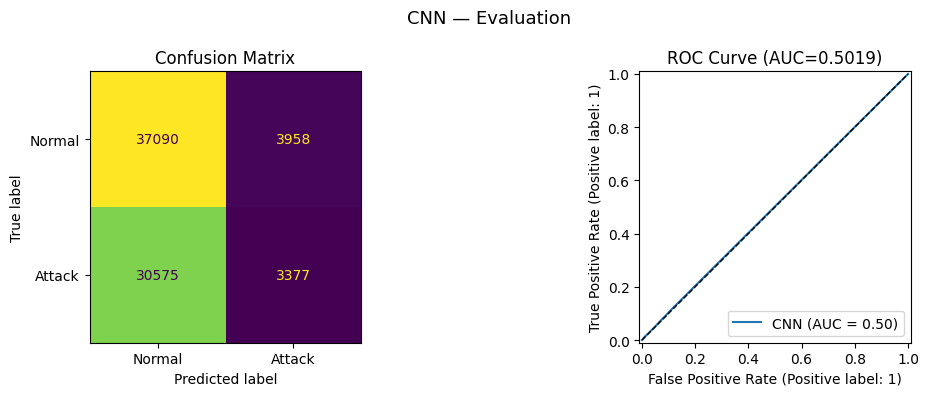

LSTM test set — 74,980 samples | classes: [0.0, 1.0] | attack rate: 87.2%



  LSTM — Test Results
  Accuracy  : 0.4456
  Precision : 0.8733
  Recall    : 0.4262
  F1 Score  : 0.5728
  ROC-AUC   : 0.4974

  Benchmark checks:
    F1  >= 0.951 : FAIL (0.5728)
    AUC >= 0.960 : FAIL (0.4974)
    Rec >= 0.968 : FAIL (0.4262)


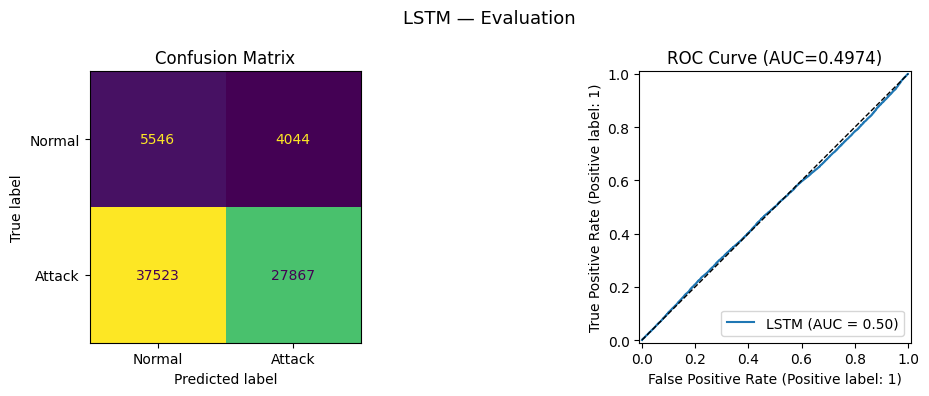

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)


def evaluate_model(model, X_test, y_test, model_name: str,
                   reshape_for_cnn: bool = False,
                   threshold: float = ANOMALY_THRESHOLD):
    """
    Full evaluation: Accuracy, Precision, Recall, F1, ROC-AUC.
    Guards against single-class edge cases.
    Plots confusion matrix and ROC curve.
    """
    classes_present = np.unique(y_test)
    logger.info(f"{model_name} test set — {len(y_test):,} samples | "
                f"classes: {classes_present.tolist()} | "
                f"attack rate: {100*y_test.mean():.1f}%")

    if len(classes_present) < 2:
        logger.error(f"{model_name}: only one class in test set — evaluation aborted. "
                     "Use a larger dataset or check preprocessing.")
        return None

    X_in = X_test.reshape(-1, BSM_FEATURE_DIM, 1) if reshape_for_cnn else X_test
    scores = model.predict(X_in, batch_size=1024, verbose=0).flatten()
    preds  = (scores >= threshold).astype(int)

    acc   = accuracy_score(y_test, preds)
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test, preds, zero_division=0)
    f1    = f1_score(y_test, preds, zero_division=0)
    auc   = roc_auc_score(y_test, scores)
    cm    = confusion_matrix(y_test, preds)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")

    # Benchmark checks (paper targets)
    print(f"\n  Benchmark checks:")
    print(f"    F1  >= 0.951 : {'PASS' if f1  >= 0.951 else 'FAIL'} ({f1:.4f})")
    print(f"    AUC >= 0.960 : {'PASS' if auc >= 0.960 else 'FAIL'} ({auc:.4f})")
    print(f"    Rec >= 0.968 : {'PASS' if rec >= 0.968 else 'FAIL'} ({rec:.4f})")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{model_name} — Evaluation", fontsize=13)

    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"]).plot(
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix")

    RocCurveDisplay.from_predictions(y_test, scores, ax=axes[1], name=model_name)
    axes[1].set_title(f"ROC Curve (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)

    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "auc": auc, "confusion_matrix": cm.tolist()}


# ── Evaluate CNN ──────────────────────────────────────────────────────────────
cnn_results = evaluate_model(
    cnn_model,
    data["cnn"]["X_test"], data["cnn"]["y_test"],
    model_name="CNN", reshape_for_cnn=True,
)

# ── Evaluate LSTM ─────────────────────────────────────────────────────────────
lstm_results = evaluate_model(
    lstm_model,
    data["lstm"]["X_test"], data["lstm"]["y_test"],
    model_name="LSTM", reshape_for_cnn=False,
)


### Training Curves


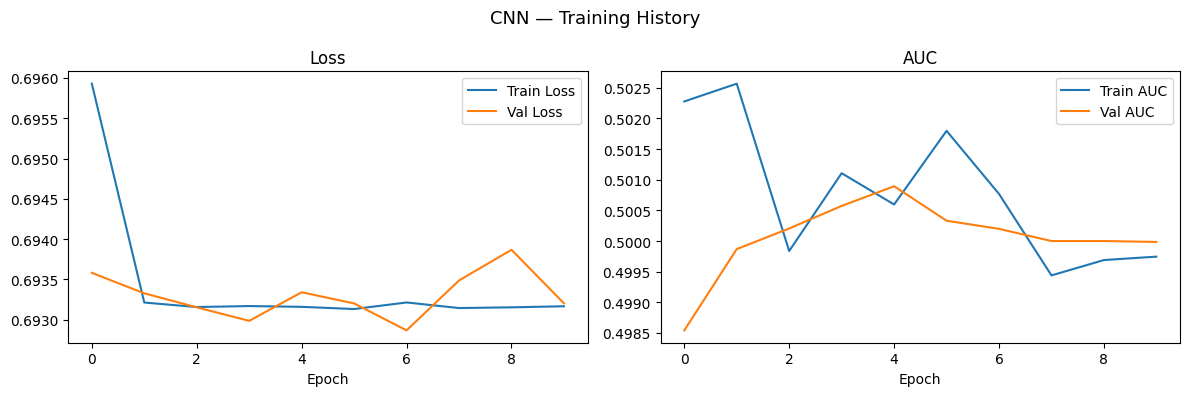

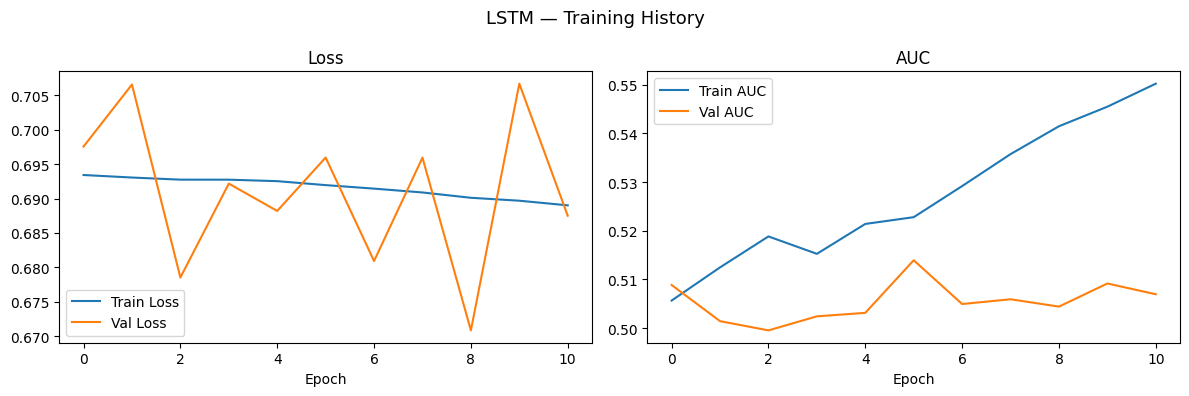

In [24]:
def plot_training(history, model_name: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{model_name} — Training History", fontsize=13)

    axes[0].plot(history.history["loss"],     label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

    axes[1].plot(history.history["auc"],     label="Train AUC")
    axes[1].plot(history.history["val_auc"], label="Val AUC")
    axes[1].set_title("AUC"); axes[1].legend(); axes[1].set_xlabel("Epoch")

    plt.tight_layout(); plt.show()

plot_training(cnn_history,  "CNN")
plot_training(lstm_history, "LSTM")


### Save Models


In [ ]:
import os

save_dir = "/content/ids_models"
os.makedirs(save_dir, exist_ok=True)

cnn_path  = os.path.join(save_dir, "cnn_ids.keras")
lstm_path = os.path.join(save_dir, "lstm_ids.keras")

cnn_model.save(cnn_path)
lstm_model.save(lstm_path)

print(f"CNN  saved → {cnn_path}")
print(f"LSTM saved → {lstm_path}")
